# M4-B: Suspicious Behaviour Classifier
## Training Notebook — UCF-Crime Dataset (YOLOv8-cls)

This notebook trains a **scene-level behaviour classifier** as the second channel
of M4 anomaly detection, complementing the existing rule-based loitering module (M4-A).

### System Architecture
```
M2 (YOLOv8 detection)
  └─ M3 (DeepSORT tracking)
       ├─ M4-A  Rule-based loitering  (dwell-time > 10s)       ← existing
       └─ M4-B  ML behaviour classifier  (this notebook)       ← NEW
            └─ M5 (false positive reduction — 15-frame filter)
                 └─ ALERT
```

### Target Classes (5)
| Class | UCF-Crime folder | Threat type |
|---|---|---|
| **Fighting** | `Fighting/` | Active — physical altercation |
| **Assault** | `Assault/` | Active — unprovoked attack |
| **Robbery** | `Robbery/` | Active — theft with force |
| **Vandalism** | `Vandalism/` | Active — property damage |
| **Normal** | `Normal-Videos-Part*/` | Baseline — no anomaly |

### Pipeline
1. **Preprocessing** — extract every 10th frame from each video → organised into class folders
2. **Train/Val split** — 80/20 stratified by video (not by frame, to avoid data leakage)
3. **Training** — fine-tune `yolov8n-cls.pt` on extracted frames
4. **Evaluation** — Accuracy, Precision, Recall, F1, Confusion Matrix, per-class report
5. **Export** — save best weights for integration into the main pipeline

## 0) Dependencies

In [ ]:
!pip install ultralytics opencv-python numpy pandas matplotlib scikit-learn tqdm

In [ ]:
!pip install -U ultralytics opencv-python numpy pandas matplotlib scikit-learn tqdm

## 0a) Download Dataset via Kaggle API

Downloads the UCF-Crime dataset directly from Kaggle using `kagglehub`.

**Prerequisites — do this once before running:**
1. Go to kaggle.com → Account → API → **Create New Token**
2. This downloads `kaggle.json` — place it at:
   - Windows: `C:\Users\<you>\.kaggle\kaggle.json`
   - Mac/Linux: `~/.kaggle/kaggle.json`
3. Run the cell below — the dataset downloads to a local cache folder

The downloaded path is automatically set as `DATASET_ROOT` in Section 1.

In [ ]:
# !pip install kagglehub   # uncomment if not installed

import kagglehub

print('Downloading UCF-Crime dataset from Kaggle...')
print('(First run: ~several GB download — subsequent runs use cache)')
print()

kaggle_path = kagglehub.dataset_download("mission-ai/crimeucfdataset")

print()
print(f'✅ Dataset downloaded to: {kaggle_path}')
print()

# Show top-level folder structure
import os
from pathlib import Path
top = Path(kaggle_path)
print('Folder structure:')
for item in sorted(top.rglob('*')):
    if item.is_dir():
        depth = len(item.relative_to(top).parts)
        if depth <= 3:
            indent = '  ' * depth
            n_files = len(list(item.glob('*.*')))
            print(f'{indent}{item.name}/  ({n_files} files)')

# ── Auto-set DATASET_ROOT for Section 1 ─────────────────────────────────────
DATASET_ROOT = str(top)
print()
print(f'DATASET_ROOT set to: {DATASET_ROOT}')
print('This will be used automatically in Section 1 below.')

## 1) Configuration
Edit `DATASET_ROOT` and `FRAMES_ROOT` to match your paths.

> ⚠️ **Do not set `MAX_FRAMES_PER_CLASS` here yet.**  
> Run Section 2 (Dataset Exploration) first to see actual frame counts per class, then return to set the cap in **Cell 1b** below.

In [1]:
import os, cv2, gc, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

# ── EDIT THESE ───────────────────────────────────────────────────────────────

# Root of the downloaded Anomaly_Dataset folder
if 'DATASET_ROOT' not in dir() or not os.path.exists(DATASET_ROOT):
    DATASET_ROOT = r'../Anomaly_Videos'

# Where to write extracted frames (will be created automatically)
FRAMES_ROOT  = r'../M4B_frames'

# Where YOLO training output goes
TRAIN_OUTPUT = r'runs/M4B_classifier'

# ── New 3-class grouping (Violence / Threat / Normal) ─────────────────────────
# Each class merges multiple UCF-Crime folders — see Section 2 for frame counts
TARGET_CLASSES = ['Violence', 'Threat', 'Normal']

CLASS_FOLDER_MAP = {
    'Violence': ['Abuse', 'Assault', 'Fighting'],
    'Threat':   ['Arson', 'Explosion', 'Burglary', 'Arrest'],
    'Normal':   ['Normal-Videos-Part-1'],
}

# Frame extraction settings
FRAME_STRIDE = 15       # 1 frame every 15 frames (~2 fps at 30fps)
TRAIN_RATIO  = 0.80     # 80/20 split BY VIDEO (prevents data leakage)

# ── MAX_FRAMES_PER_CLASS ──────────────────────────────────────────────────────
# Set AFTER running Section 2 (Dataset Exploration).
# Rule: use the smallest class's estimated frame count, rounded down to nearest
# 1000, then cap at 10000 to keep training time manageable.
# Placeholder — update in Cell 1b below after you see the real counts.
MAX_FRAMES_PER_CLASS = {
    'Violence': 10000,
    'Threat':   10000,
    'Normal':   10000,
}

# Base model (shared across all experiments)
BASE_MODEL = 'yolov8s-cls.pt'
WORKERS    = 8

# ── 3-run ablation grid ───────────────────────────────────────────────────────
EXPERIMENTS = [
    {
        'name': 'Run1_FreezeBackbone',
        'epochs': 50, 'lr0': 0.01, 'batch': 16,     # <--- Change from 32 to 16
        'imgsz': 224, 'dropout': 0.0, 'patience': 15,
        'freeze': 9,
        'description': 'Freeze backbone — only train classifier head',
    },
    {
        'name': 'Run2_FineTune',
        'epochs': 50, 'lr0': 0.005, 'batch': 16,    # <--- Change from 32 to 16
        'imgsz': 224, 'dropout': 0.0, 'patience': 15,
        'freeze': None,
        'description': 'Full fine-tune, moderate LR',
    },
    {
        'name': 'Run3_FreezeDropout',
        'epochs': 50, 'lr0': 0.01, 'batch': 16,     # <--- Change from 32 to 16
        'imgsz': 224, 'dropout': 0.3, 'patience': 15,
        'freeze': 9,
        'description': 'Freeze backbone + dropout regularisation',
    },
]


# ── Verify dataset root ───────────────────────────────────────────────────────
if os.path.exists(DATASET_ROOT):
    print(f'✅ DATASET_ROOT found: {DATASET_ROOT}')
    for p in sorted(Path(DATASET_ROOT).iterdir()):
        if p.is_dir():
            sub = [s.name for s in p.iterdir() if s.is_dir()]
            print(f'   {p.name}/ → {sub[:8]}{"..." if len(sub)>8 else ""}')
else:
    print(f'❌ DATASET_ROOT not found: {DATASET_ROOT}')

print()
print(f'Target classes  : {TARGET_CLASSES}')
print(f'Class folder map:')
for cls, folders in CLASS_FOLDER_MAP.items():
    print(f'  {cls:<12} ← {folders}')
print()
print(f'Ablation experiments: {len(EXPERIMENTS)}')
print(f'{"Run":<22} {"epochs":>7} {"lr0":>8} {"batch":>6} {"imgsz":>6} {"dropout":>8}  Description')
print('-'*85)
for e in EXPERIMENTS:
    print(f'  {e["name"]:<20} {e["epochs"]:>7} {e["lr0"]:>8.4f} '
          f'{e["batch"]:>6} {e["imgsz"]:>6} {e["dropout"]:>8.1f}  {e["description"]}')


✅ DATASET_ROOT found: ../Anomaly_Videos
   Anomaly-Videos-Part-1/ → ['Abuse', 'Arrest', 'Arson', 'Assault']
   Anomaly-Videos-Part-2/ → ['Burglary', 'Explosion', 'Fighting']
   Normal-Videos-Part-1/ → []

Target classes  : ['Violence', 'Threat', 'Normal']
Class folder map:
  Violence     ← ['Abuse', 'Assault', 'Fighting']
  Threat       ← ['Arson', 'Explosion', 'Burglary', 'Arrest']
  Normal       ← ['Normal-Videos-Part-1']

Ablation experiments: 3
Run                     epochs      lr0  batch  imgsz  dropout  Description
-------------------------------------------------------------------------------------
  Run1_FreezeBackbone       50   0.0100     16    224      0.0  Freeze backbone — only train classifier head
  Run2_FineTune             50   0.0050     16    224      0.0  Full fine-tune, moderate LR
  Run3_FreezeDropout        50   0.0100     16    224      0.3  Freeze backbone + dropout regularisation


## 2) Dataset Exploration
Scan actual video counts and estimate extractable frames **before** committing to a frame cap.
This lets you set `MAX_FRAMES_PER_CLASS` based on real numbers instead of guessing.

In [2]:
def find_class_videos(dataset_root, class_name):
    """
    Find all videos for a given TARGET_CLASS.
    Uses CLASS_FOLDER_MAP to merge multiple UCF-Crime folders into one class.
    """
    root = Path(dataset_root)
    videos = []
    folders = CLASS_FOLDER_MAP.get(class_name, [class_name])

    for folder_name in folders:
        for folder in root.rglob('*'):
            if folder.is_dir() and folder.name == folder_name:
                for ext in ['*.mp4', '*.avi', '*.MP4', '*.AVI']:
                    videos.extend(folder.glob(ext))
            # Handle Normal-Videos-Part-1 style names
            elif folder.is_dir() and folder_name.lower() in folder.name.lower():
                for ext in ['*.mp4', '*.avi', '*.MP4', '*.AVI']:
                    videos.extend(folder.glob(ext))

    return sorted(set(videos))


# ── Quick scan: video count + estimated frames ────────────────────────────────
print('Scanning dataset...')
print()
print(f'  {"Class":<12} {"Source folders":<40} {"Videos":>8} {"Est. frames":>14}')
print(f'  {"-"*78}')

class_videos = {}
for cls in TARGET_CLASSES:
    vids = find_class_videos(DATASET_ROOT, cls)
    class_videos[cls] = vids
    # Estimate: assume avg 5 min @ 30fps / FRAME_STRIDE
    est = len(vids) * 300 * 30 // FRAME_STRIDE
    src = str(CLASS_FOLDER_MAP.get(cls, [cls]))[:38]
    print(f'  {cls:<12} {src:<40} {len(vids):>8,} {est:>14,}')

print(f'  {"-"*78}')
total_v = sum(len(v) for v in class_videos.values())
total_e = sum(len(v)*300*30//FRAME_STRIDE for v in class_videos.values())
print(f'  {"TOTAL":<12} {"":<40} {total_v:>8,} {total_e:>14,}')
print()
print('ℹ️  Estimated frames = videos × 300s × 30fps ÷ FRAME_STRIDE (rough estimate)')
print('   Run Cell 2b below for exact counts by reading every video.')


Scanning dataset...

  Class        Source folders                             Videos    Est. frames
  ------------------------------------------------------------------------------
  Violence     ['Abuse', 'Assault', 'Fighting']              150         90,000
  Threat       ['Arson', 'Explosion', 'Burglary', 'Ar        250        150,000
  Normal       ['Normal-Videos-Part-1']                      150         90,000
  ------------------------------------------------------------------------------
  TOTAL                                                      550        330,000

ℹ️  Estimated frames = videos × 300s × 30fps ÷ FRAME_STRIDE (rough estimate)
   Run Cell 2b below for exact counts by reading every video.


### 2b) Detailed Video Scan
Reads every video file to get **exact** frame counts, duration, and resolution.
This takes 1–3 minutes but gives you precise numbers to set `MAX_FRAMES_PER_CLASS`.

In [3]:
import math

def get_video_info(video_path, target_class):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {"video_name": video_path.name, "target_class": target_class,
                "source_folder": video_path.parent.name,
                "file_size_mb": round(video_path.stat().st_size/1024/1024, 2),
                "fps": None, "total_frames": None, "duration_sec": None,
                "resolution": None, "est_extracted": None, "readable": False}

    fps         = cap.get(cv2.CAP_PROP_FPS)
    total_f     = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w           = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h           = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    dur         = total_f / fps if fps and fps > 0 else None
    est         = math.ceil(total_f / FRAME_STRIDE) if total_f else 0
    return {"video_name": video_path.name, "target_class": target_class,
            "source_folder": video_path.parent.name,
            "file_size_mb": round(video_path.stat().st_size/1024/1024, 2),
            "fps": round(fps, 2) if fps else None,
            "total_frames": total_f,
            "duration_sec": round(dur, 1) if dur else None,
            "resolution": f"{w}x{h}" if w and h else None,
            "est_extracted": est, "readable": True}

rows = []
for cls in TARGET_CLASSES:
    vids = class_videos[cls]
    print(f'  Scanning {cls} ({len(vids)} videos)...', end=' ', flush=True)
    for vp in vids:
        rows.append(get_video_info(vp, cls))
    print('done')

video_df = pd.DataFrame(rows)

# ── Class-level summary ───────────────────────────────────────────────────────
summary = (
    video_df.groupby('target_class')
    .agg(
        videos        = ('video_name',    'count'),
        source_folders= ('source_folder', lambda x: list(x.unique())),
        total_frames  = ('total_frames',  'sum'),
        est_extracted = ('est_extracted', 'sum'),
        avg_fps       = ('fps',           'mean'),
        avg_dur_sec   = ('duration_sec',  'mean'),
        total_dur_min = ('duration_sec',  lambda x: round(x.sum()/60, 1)),
        total_size_mb = ('file_size_mb',  'sum'),
    )
    .reset_index()
)
summary['avg_fps']      = summary['avg_fps'].round(1)
summary['avg_dur_sec']  = summary['avg_dur_sec'].round(1)
summary['total_size_gb']= (summary['total_size_mb']/1024).round(2)

print()
print('='*75)
print('  CLASS-LEVEL SUMMARY')
print('='*75)
display(summary[['target_class','videos','source_folders',
                  'total_frames','est_extracted',
                  'avg_fps','avg_dur_sec','total_dur_min','total_size_gb']])

print()
print('='*75)
print('  RECOMMENDED MAX_FRAMES_PER_CLASS')
print('='*75)
min_est = int(summary['est_extracted'].min())
recommended = min(10000, (min_est // 1000) * 1000)
print(f'  Smallest class extractable frames : {min_est:,}')
print(f'  Recommended cap (balanced, ≤10000): {recommended:,}')
print()
print(f'  Update Cell 1b with:')
print(f'  MAX_FRAMES_PER_CLASS = {{')
for cls in TARGET_CLASSES:
    print(f'      "{cls}": {recommended},')
print(f'  }}')


  Scanning Violence (150 videos)... done
  Scanning Threat (250 videos)... done
  Scanning Normal (150 videos)... done

  CLASS-LEVEL SUMMARY


,target_class,videos,source_folders,total_frames,est_extracted,avg_fps,avg_dur_sec,total_dur_min,total_size_gb
0,Normal,150,[Normal-Videos-Part-1],648905,43319,30.0,144.2,360.5,4.41
1,Threat,250,"[Arrest, Arson, Burglary, Explosion]",1292908,86311,30.0,172.4,718.3,8.40
2,Violence,150,"[Abuse, Assault, Fighting]",582338,38892,30.0,129.4,323.5,3.96



  RECOMMENDED MAX_FRAMES_PER_CLASS
  Smallest class extractable frames : 38,892
  Recommended cap (balanced, ≤10000): 10,000

  Update Cell 1b with:
  MAX_FRAMES_PER_CLASS = {
      "Violence": 10000,
      "Threat": 10000,
      "Normal": 10000,
  }


### 1b) Set MAX_FRAMES_PER_CLASS
After reviewing the scan above, update the cap here and run this cell.
This overrides the placeholder set in Cell 1.

In [4]:
# ── UPDATE THIS based on Cell 2b output ──────────────────────────────────────
# Rule: set all classes to the same value (balanced training)
# Use the recommended value printed above, or adjust manually.

MAX_FRAMES_PER_CLASS = {
    'Violence': 10000,   # ← update after seeing Cell 2b
    'Threat':   10000,   # ← update after seeing Cell 2b
    'Normal':   10000,   # ← update after seeing Cell 2b
}

print('MAX_FRAMES_PER_CLASS set to:')
for cls, cap in MAX_FRAMES_PER_CLASS.items():
    print(f'  {cls:<12}: {cap:,} frames  '
          f'(train≈{int(cap*0.8):,}  val≈{int(cap*0.2):,})')
print()
print(f'Total frames to extract: {sum(MAX_FRAMES_PER_CLASS.values()):,}')
print(f'  → train: {int(sum(MAX_FRAMES_PER_CLASS.values())*0.8):,}')
print(f'  → val  : {int(sum(MAX_FRAMES_PER_CLASS.values())*0.2):,}')


MAX_FRAMES_PER_CLASS set to:
  Violence    : 10,000 frames  (train≈8,000  val≈2,000)
  Threat      : 10,000 frames  (train≈8,000  val≈2,000)
  Normal      : 10,000 frames  (train≈8,000  val≈2,000)

Total frames to extract: 30,000
  → train: 24,000
  → val  : 6,000


## 3) Frame Extraction
Extracts frames split **by video** (not by frame) to prevent data leakage between train and val.
Frame cap is applied independently per split — fixing the original bug where val ended up with 0 frames.

In [ ]:
def extract_frames_for_class(videos, class_name, frames_root,
                             stride, train_ratio,
                             max_frames=None, seed=42):
    """
    Extract frames split BY VIDEO into train/val.
    FIX: max_frames cap applied PER SPLIT independently (80% train / 20% val).
    Previously the global cap caused val=0 for larger classes.
    """
    import random as _random
    _random.seed(seed)
    shuffled = list(videos)
    _random.shuffle(shuffled)

    n_train    = max(1, int(len(shuffled) * train_ratio))
    train_vids = shuffled[:n_train]
    val_vids   = shuffled[n_train:]

    max_train = int(max_frames * train_ratio) if max_frames else None
    max_val   = (max_frames - max_train)      if (max_frames and max_train) else None

    stats = {'train_frames': 0, 'val_frames': 0,
             'train_videos': len(train_vids), 'val_videos': len(val_vids),
             'skipped': 0}

    for split, vid_list, split_cap in [
        ('train', train_vids, max_train),
        ('val',   val_vids,   max_val),
    ]:
        out_dir = Path(frames_root) / split / class_name
        out_dir.mkdir(parents=True, exist_ok=True)
        split_total = 0

        for vpath in vid_list:
            cap = cv2.VideoCapture(str(vpath))
            if not cap.isOpened():
                stats['skipped'] += 1
                continue
            f_i = 0; saved = 0
            stem = vpath.stem[:30]
            while True:
                ret, frame = cap.read()
                if not ret: break
                if f_i % stride == 0:
                    fname = out_dir / f'{stem}_f{f_i:05d}.jpg'
                    cv2.imwrite(str(fname), frame,
                                [cv2.IMWRITE_JPEG_QUALITY, 90])
                    saved += 1; split_total += 1
                    if split_cap and split_total >= split_cap:
                        cap.release(); break
                f_i += 1
            else:
                cap.release()
            if split == 'train': stats['train_frames'] += saved
            else:                stats['val_frames']   += saved
            if split_cap and split_total >= split_cap: break

    return stats


# ── Run extraction ────────────────────────────────────────────────────────────
print(f'Extracting frames to : {FRAMES_ROOT}')
print(f'Frame stride         : every {FRAME_STRIDE} frames')
print(f'Train/Val split      : {int(TRAIN_RATIO*100)}/{100-int(TRAIN_RATIO*100)} by video')
print(f'Max frames/class     : {MAX_FRAMES_PER_CLASS}')
print()

extraction_stats = {}
for cls in TARGET_CLASSES:
    videos = class_videos[cls]
    if not videos:
        print(f'  ⚠️  No videos found for {cls} — skipping')
        continue

    train_dir = Path(FRAMES_ROOT) / 'train' / cls
    val_dir   = Path(FRAMES_ROOT) / 'val'   / cls
    if train_dir.exists() and val_dir.exists():
        n_t = len(list(train_dir.glob('*.jpg')))
        n_v = len(list(val_dir.glob('*.jpg')))
        if n_t > 0 and n_v > 0:
            print(f'  ✅ {cls}: already extracted (train={n_t:,}  val={n_v:,}) — skipping')
            extraction_stats[cls] = {'train_frames': n_t, 'val_frames': n_v,
                                     'train_videos': '?', 'val_videos': '?'}
            continue

    print(f'  Extracting {cls} ({len(videos)} videos)...', end=' ', flush=True)
    st = extract_frames_for_class(
        videos, cls, FRAMES_ROOT,
        stride=FRAME_STRIDE, train_ratio=TRAIN_RATIO,
        max_frames=MAX_FRAMES_PER_CLASS.get(cls),
    )
    extraction_stats[cls] = st
    print(f'train={st["train_frames"]:,}  val={st["val_frames"]:,}  '
          f'(videos: {st["train_videos"]}t / {st["val_videos"]}v)')

print()
print('='*65)
print(f'  {"Class":<14} {"Train frames":>14} {"Val frames":>12} {"Total":>10}')
print('  ' + '-'*54)
total_t = total_v = 0
for cls in TARGET_CLASSES:
    st  = extraction_stats.get(cls, {})
    t   = st.get('train_frames', 0)
    v   = st.get('val_frames', 0)
    total_t += t; total_v += v
    print(f'  {cls:<14} {t:>14,} {v:>12,} {t+v:>10,}')
print('  ' + '-'*54)
print(f'  {"TOTAL":<14} {total_t:>14,} {total_v:>12,} {total_t+total_v:>10,}')
print('='*65)
print()

missing_val = [cls for cls in TARGET_CLASSES
               if extraction_stats.get(cls, {}).get('val_frames', 0) == 0]
if missing_val:
    print(f'❌ WARNING: These classes have 0 val frames: {missing_val}')
    print('   Delete the M4B_frames folder and re-run this cell.')
else:
    print('✅ All classes have both train and val frames — ready for training.')


## 4) Class Balance Check
Verify extracted frame counts and visualise class distribution.

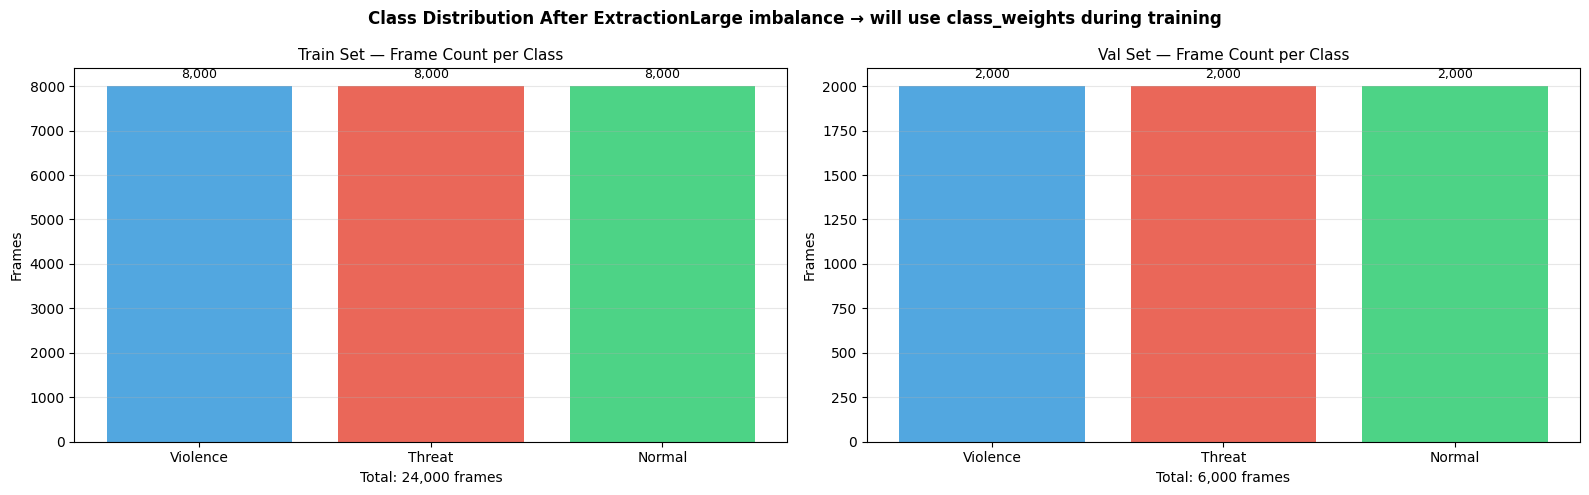

Imbalance ratio (max/min): 1.0x
✅ Moderate imbalance — class weights applied as precaution


In [5]:
# Count actual files on disk
actual_counts = {'train':{}, 'val':{}}
for split in ['train','val']:
    for cls in TARGET_CLASSES:
        d = Path(FRAMES_ROOT) / split / cls
        if d.exists():
            actual_counts[split][cls] = len(list(d.glob('*.jpg')))
        else:
            actual_counts[split][cls] = 0

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6']

for ax, split in zip(axes, ['train','val']):
    counts = [actual_counts[split].get(c,0) for c in TARGET_CLASSES]
    bars = ax.bar(TARGET_CLASSES, counts, color=colors, alpha=0.85)
    ax.bar_label(bars, labels=[f'{v:,}' for v in counts], padding=4, fontsize=9)
    ax.set_title(f'{split.capitalize()} Set — Frame Count per Class', fontsize=11)
    ax.set_ylabel('Frames')
    ax.grid(axis='y', alpha=0.3)
    total = sum(counts)
    ax.set_xlabel(f'Total: {total:,} frames', fontsize=10)

plt.suptitle('Class Distribution After Extraction'
             'Large imbalance → will use class_weights during training',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Check imbalance ratio
train_counts = [actual_counts['train'].get(c,1) for c in TARGET_CLASSES]
ratio = max(train_counts) / max(min(train_counts), 1)
print(f'Imbalance ratio (max/min): {ratio:.1f}x')
if ratio > 5:
    print('⚠️  High imbalance — class weights will be applied automatically')
else:
    print('✅ Moderate imbalance — class weights applied as precaution')

## 5) Sample Frames Preview
Visual sanity check — 3 random training frames from each class.

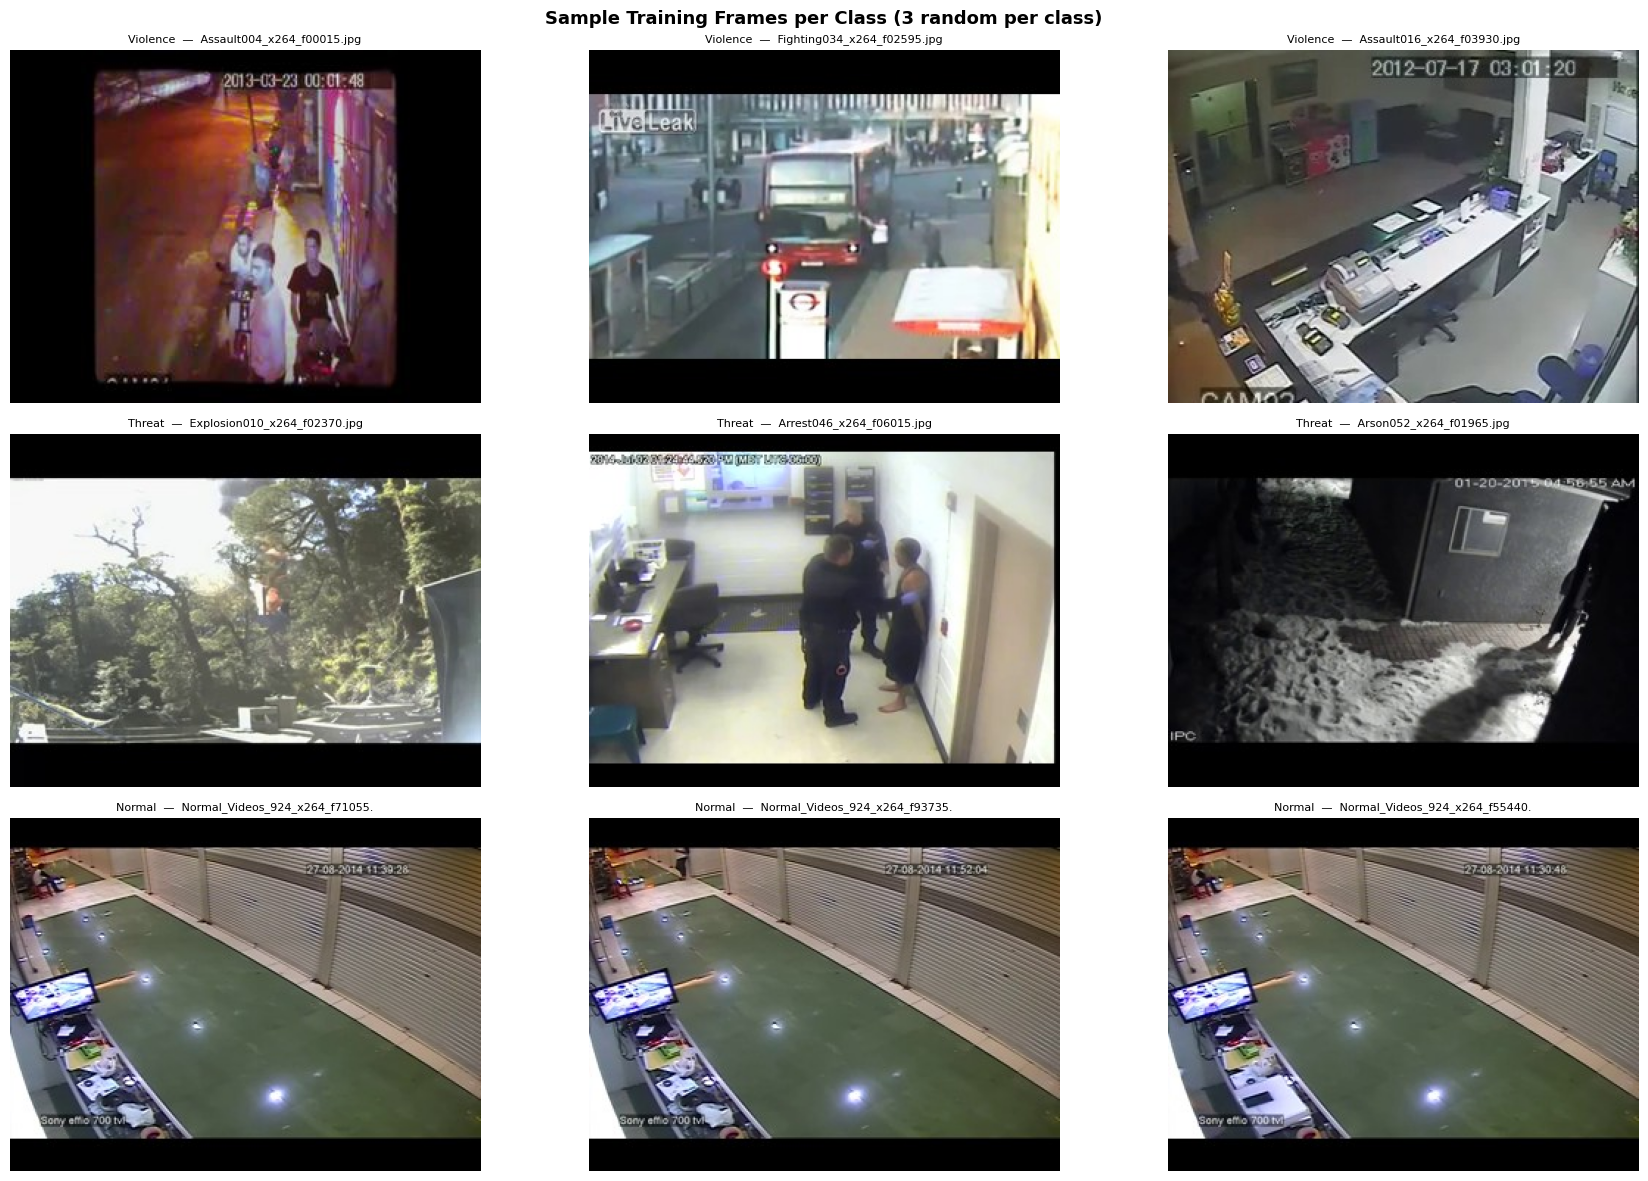

In [6]:
fig, axes = plt.subplots(len(TARGET_CLASSES), 3,
                         figsize=(18, 4*len(TARGET_CLASSES)))

for row, cls in enumerate(TARGET_CLASSES):
    cls_dir = Path(FRAMES_ROOT) / 'train' / cls
    frames_available = list(cls_dir.glob('*.jpg')) if cls_dir.exists() else []

    picks = random.sample(frames_available, min(3, len(frames_available)))
    while len(picks) < 3:
        picks.append(None)

    for col, fpath in enumerate(picks):
        ax = axes[row][col]
        if fpath and fpath.exists():
            img = cv2.cvtColor(cv2.imread(str(fpath)), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f'{cls}  —  {fpath.name[:30]}', fontsize=8)
        else:
            ax.text(0.5, 0.5, 'No frame', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='grey')
        ax.axis('off')

plt.suptitle('Sample Training Frames per Class (3 random per class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6) Training — YOLOv8-cls Fine-tuning
Fine-tunes `yolov8n-cls.pt` across 3 ablation runs.

**Fixes vs original notebook:**
- `optimizer='SGD'` explicit — prevents `auto` silently overriding `lr0`
- Val set pre-check raises error if any class is missing before training starts
- `cos_lr=True` for smoother decay
- `get_device_batch` skips GPU scaling when `base_batch ≤ 16` (OOM guard)
- `torch.cuda.synchronize()` before `empty_cache()` for proper VRAM flush between runs

In [ ]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [7]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version used by torch:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
CUDA version used by torch: 12.8
GPU count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [8]:
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, f1_score
from pathlib import Path
import time, torch, gc, random, numpy as np, pandas as pd

# ── Device detection ──────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = 'cuda'
    GPU_NAME = torch.cuda.get_device_name(0)
    VRAM_GB  = torch.cuda.get_device_properties(0).total_memory / 1e9
    GPU_BATCH_SCALE = max(1, int(VRAM_GB / 4))
    torch.backends.cudnn.benchmark = True
    print(f'✅ CUDA: {GPU_NAME} ({VRAM_GB:.1f} GB VRAM)  batch_scale={GPU_BATCH_SCALE}x')
elif torch.backends.mps.is_available():
    DEVICE = 'mps'; GPU_BATCH_SCALE = 1
    print('✅ Apple MPS available')
else:
    DEVICE = 'cpu'; GPU_BATCH_SCALE = 1
    print('⚠️ No GPU — training on CPU')

print(f'Device: {DEVICE}  Workers: {WORKERS}')


def get_device_batch(base_batch):
    # Skip scaling for small batches — avoids OOM on 8GB VRAM laptops
    if DEVICE == 'cuda' and base_batch > 16:
        return min(base_batch * GPU_BATCH_SCALE, 128)
    return base_batch


def fmt_time(s):
    m, s = divmod(int(s), 60); h, m = divmod(m, 60)
    return f'{h}h{m:02d}m' if h > 0 else f'{m}m{s:02d}s'


def make_progress_callback(total_epochs, t0_ref):
    def on_epoch_end(trainer):
        ep      = trainer.epoch + 1
        elapsed = time.time() - t0_ref[0]
        eta     = elapsed / ep * (total_epochs - ep)
        metrics = trainer.metrics or {}
        top1    = metrics.get('metrics/accuracy_top1',
                  metrics.get('val/acc_top1',
                  metrics.get('metrics/acc_top1', float('nan'))))
        lr_now  = trainer.optimizer.param_groups[0]['lr'] if trainer.optimizer else float('nan')
        loss_v  = getattr(trainer, 'loss', None)
        loss_s  = f'{float(loss_v.detach()):.4f}' if loss_v is not None else '—'
        filled  = int(28 * ep / total_epochs)
        bar     = '█'*filled + '░'*(28-filled)
        pat_warn = ''
        if hasattr(trainer, 'stopper') and trainer.stopper:
            rem = trainer.stopper.patience - (trainer.epoch - trainer.stopper.best_epoch)
            if rem <= 3: pat_warn = f'  ⚠️ patience ({rem} left)'
        print(f'  [{bar}] {ep:>3}/{total_epochs} ({100*ep/total_epochs:5.1f}%)'
              f'  loss={loss_s}  val_acc={top1:.4f}  lr={lr_now:.2e}'
              f'  {fmt_time(elapsed)} / ETA {fmt_time(eta)}{pat_warn}')
    return on_epoch_end


# ── Pre-flight: validate val set has ALL classes ──────────────────────────────
print('\nValidating val set...')
val_class_counts = {}
for cls in TARGET_CLASSES:
    d = Path(FRAMES_ROOT) / 'val' / cls
    n = len(list(d.glob('*.jpg'))) if d.exists() else 0
    val_class_counts[cls] = n
    print(f'  {cls}: {n:,} val frames  {"✅" if n > 0 else "❌ MISSING"}')

missing = [c for c, n in val_class_counts.items() if n == 0]
if missing:
    raise RuntimeError(
        f'Val set missing classes: {missing}\n'
        f'Delete {FRAMES_ROOT} and re-run Cell 3 (frame extraction).'
    )
print('✅ Val set OK\n')


# ── Training loop ─────────────────────────────────────────────────────────────
all_results = []

for run_i, exp in enumerate(EXPERIMENTS):
    print('='*68)
    print(f'  [{run_i+1}/{len(EXPERIMENTS)}] {exp["name"]}')
    print(f'  {exp["description"]}')
    effective_batch = get_device_batch(exp['batch'])
    print(f'  epochs={exp["epochs"]}  lr0={exp["lr0"]}'
          f'  batch={exp["batch"]}→{effective_batch}  imgsz={exp["imgsz"]}'
          f'  dropout={exp["dropout"]}')
    print('='*68)

    model = YOLO(BASE_MODEL)
    t0    = [time.time()]
    model.add_callback('on_train_epoch_end',
                       make_progress_callback(exp['epochs'], t0))

    results = model.train(
        data      = FRAMES_ROOT,
        epochs    = exp['epochs'],
        imgsz     = exp['imgsz'],
        batch     = effective_batch,
        lr0       = exp['lr0'],
        lrf       = 0.01,
        optimizer = 'SGD',
        cos_lr    = True,
        dropout   = exp['dropout'],
        patience  = exp['patience'],
        workers   = WORKERS,
        device    = DEVICE,
        # amp       = (DEVICE == 'cuda') and exp.get('freeze', None) is None,  # ← changed
        cache     = 'disk',
        project   = TRAIN_OUTPUT,
        name      = exp['name'],
        exist_ok  = True,
        verbose   = False,
        plots     = True,
        freeze    = exp.get('freeze', None),   # ← add this
    )
    elapsed = time.time() - t0[0]

    # ── Evaluate on val set ───────────────────────────────────────────────────
    best_weights = Path(results.save_dir) / 'weights' / 'best.pt'
    val_model    = YOLO(str(best_weights))
    print(f'\n  Evaluating val set...', end=' ', flush=True)

    y_true, y_pred = [], []
    val_root = Path(FRAMES_ROOT) / 'val'

    with torch.no_grad():
        imgs_batch, labels_batch = [], []
        for ci, cls in enumerate(TARGET_CLASSES):
            cls_dir = val_root / cls
            if not cls_dir.exists(): continue
            for img_path in cls_dir.glob('*.jpg'):
                imgs_batch.append(str(img_path))
                labels_batch.append(ci)
                if len(imgs_batch) >= effective_batch:
                    for res, lbl in zip(
                        val_model(imgs_batch, imgsz=exp['imgsz'], verbose=False),
                        labels_batch
                    ):
                        pred_nm  = res.names[res.probs.top1]
                        pred_idx = TARGET_CLASSES.index(pred_nm) if pred_nm in TARGET_CLASSES else -1
                        y_true.append(lbl); y_pred.append(pred_idx)
                    imgs_batch, labels_batch = [], []
        if imgs_batch:
            for res, lbl in zip(
                val_model(imgs_batch, imgsz=exp['imgsz'], verbose=False),
                labels_batch
            ):
                pred_nm  = res.names[res.probs.top1]
                pred_idx = TARGET_CLASSES.index(pred_nm) if pred_nm in TARGET_CLASSES else -1
                y_true.append(lbl); y_pred.append(pred_idx)
    print('done')

    val_acc = accuracy_score(y_true, y_pred)
    wf1     = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    csv_path = Path(results.save_dir) / 'results.csv'
    df_curves = pd.read_csv(csv_path) if csv_path.exists() else pd.DataFrame()
    best_epoch = -1; best_val_acc = val_acc
    try:
        acc_col   = next(c for c in df_curves.columns
                         if 'accuracy_top1' in c or 'acc_top1' in c)
        best_epoch    = int(df_curves[acc_col].idxmax()) + 1
        best_val_acc  = float(df_curves[acc_col].max())
    except Exception:
        pass

    all_results.append({
        'name': exp['name'], 'description': exp['description'],
        'lr0': exp['lr0'], 'batch': effective_batch,
        'imgsz': exp['imgsz'], 'dropout': exp['dropout'],
        'epochs': exp['epochs'], 'best_epoch': best_epoch,
        'best_val_acc': best_val_acc, 'val_acc': val_acc,
        'weighted_f1': wf1, 'weights': str(best_weights),
        'elapsed_s': elapsed, 'df_curves': df_curves,
        'y_true': y_true, 'y_pred': y_pred,
    })

    print(f'\n  ✅ {exp["name"]} complete in {fmt_time(elapsed)}')
    print(f'     Best epoch  : {best_epoch} / {exp["epochs"]}')
    print(f'     Best val acc: {best_val_acc:.4f}')
    print(f'     Val accuracy: {val_acc:.4f}')
    print(f'     Weighted F1 : {wf1:.4f}')
    print(f'     Weights     : {best_weights}')
    print()

    del model, val_model
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.synchronize()   # wait for all GPU ops before clearing cache
        torch.cuda.empty_cache()

# ── Best run ──────────────────────────────────────────────────────────────────
best_run    = max(all_results, key=lambda r: r['weighted_f1'])
M4B_WEIGHTS = best_run['weights']

print('='*68)
print(f'🏆 Best run    : {best_run["name"]}')
print(f'   Weighted F1 : {best_run["weighted_f1"]:.4f}')
print(f'   Val Accuracy: {best_run["val_acc"]:.4f}')
print(f'   Weights     : {M4B_WEIGHTS}')
print('='*68)

✅ CUDA: NVIDIA GeForce RTX 4060 Laptop GPU (8.6 GB VRAM)  batch_scale=2x
Device: cuda  Workers: 8

Validating val set...
  Violence: 2,000 val frames  ✅
  Threat: 2,000 val frames  ✅
  Normal: 2,000 val frames  ✅
✅ Val set OK

  [1/3] Run1_FreezeBackbone
  Freeze backbone — only train classifier head
  epochs=50  lr0=0.01  batch=16→16  imgsz=224  dropout=0.0
New https://pypi.org/project/ultralytics/8.4.22 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.13.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=../M4B_frames, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=

## 7) Training Curves

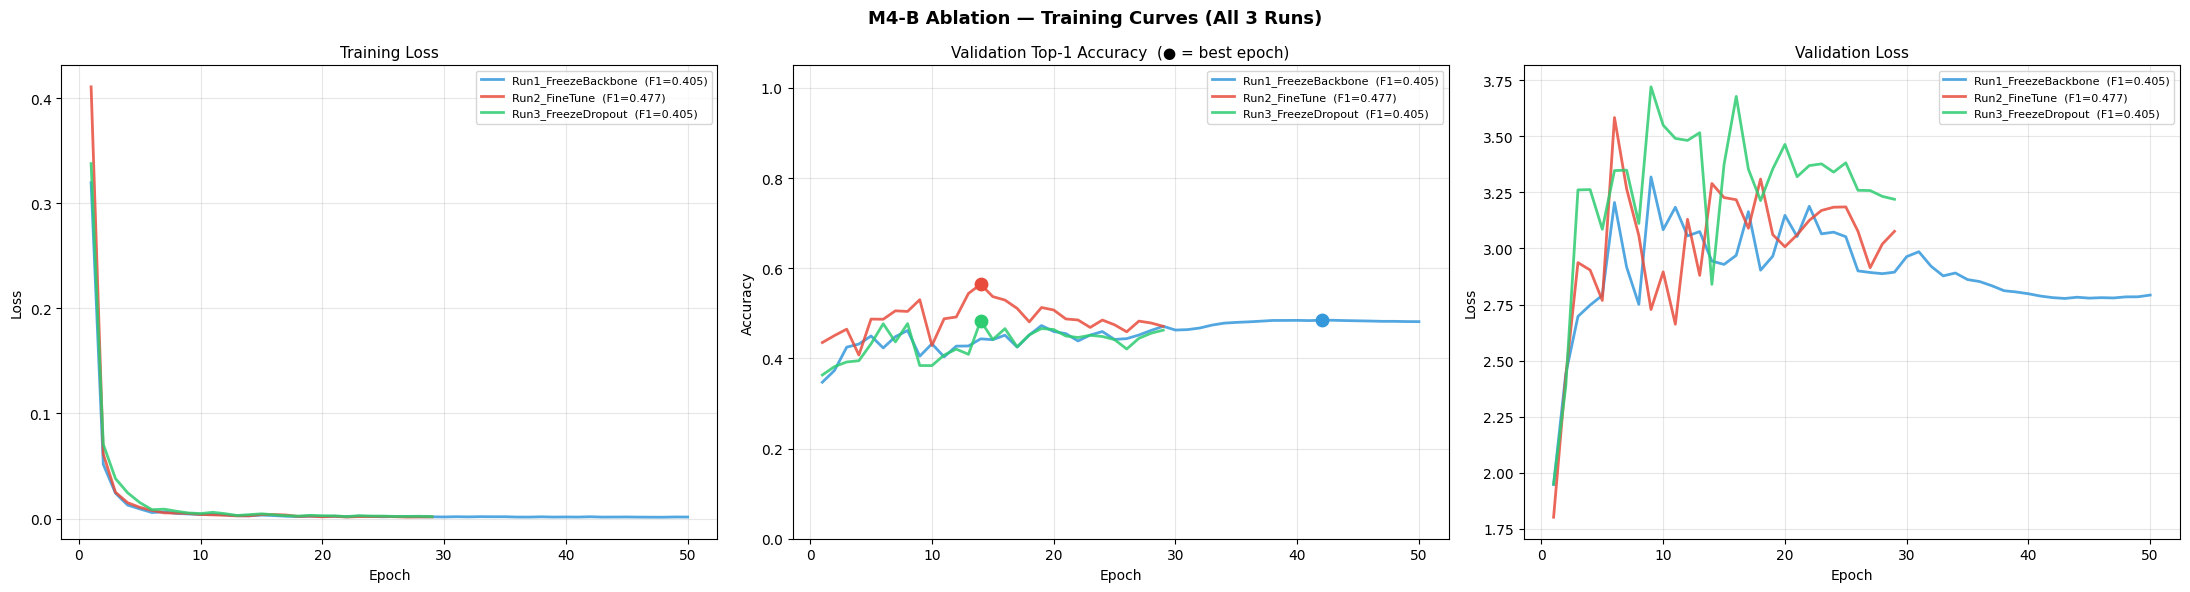


Final 5 epochs — Validation Accuracy:
  Epoch     Run1_FreezeBackbon    Run2_FineTune         Run3_FreezeDropout  
  ------------------------------------------------------------------------------------------
  46        0.4828               —                     —                   
  47        0.4822               —                     —                   
  48        0.4822               —                     —                   
  49        0.4817               —                     —                   
  50        0.4815               —                     —                   


In [9]:
# ── Training curves: all 4 runs overlaid ─────────────────────────────────────
COLORS = ['#3498DB','#E74C3C','#2ECC71','#F39C12']
n_runs = len(all_results)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for res, color in zip(all_results, COLORS):
    df = res['df_curves']
    if df.empty: continue
    epochs_x = range(1, len(df)+1)
    label    = f'{res["name"]}  (F1={res["weighted_f1"]:.3f})'

    # Loss
    for col in ['train/loss','train_loss']:
        if col in df.columns:
            axes[0].plot(epochs_x, df[col], color=color,
                         linewidth=2, label=label, alpha=0.85)
            break

    # Top-1 Accuracy
    for col in ['metrics/accuracy_top1','val/acc_top1','metrics/acc_top1']:
        if col in df.columns:
            axes[1].plot(epochs_x, df[col], color=color,
                         linewidth=2, label=label, alpha=0.85)
            # Mark best epoch
            best_ep = df[col].idxmax()
            axes[1].scatter(best_ep+1, df[col].iloc[best_ep],
                            color=color, s=80, zorder=5)
            break

    # Val Loss
    for col in ['val/loss','metrics/val_loss']:
        if col in df.columns:
            axes[2].plot(epochs_x, df[col], color=color,
                         linewidth=2, label=label, alpha=0.85)
            break

for ax, title, ylabel in [
    (axes[0], 'Training Loss',     'Loss'),
    (axes[1], 'Validation Top-1 Accuracy  (● = best epoch)', 'Accuracy'),
    (axes[2], 'Validation Loss',   'Loss'),
]:
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[1].set_ylim(0, 1.05)

plt.suptitle(f'M4-B Ablation — Training Curves (All {len(all_results)} Runs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Epoch-by-epoch accuracy table (final 5 epochs of each run) ───────────────
print('\nFinal 5 epochs — Validation Accuracy:')
print(f'  {"Epoch":<8}', end='')
for res in all_results:
    print(f'  {res["name"][:18]:<20}', end='')
print()
print('  ' + '-'*90)

# Find max epochs
max_ep = max(len(r['df_curves']) for r in all_results if not r['df_curves'].empty)
show_from = max(0, max_ep - 5)

for ep_i in range(show_from, max_ep):
    print(f'  {ep_i+1:<8}', end='')
    for res in all_results:
        df = res['df_curves']
        if df.empty or ep_i >= len(df):
            print(f'  {"—":<20}', end='')
            continue
        for col in ['metrics/accuracy_top1','val/acc_top1','metrics/acc_top1']:
            if col in df.columns:
                val = df[col].iloc[ep_i]
                mark = ' ← best' if ep_i == df[col].idxmax() else ''
                print(f'  {val:.4f}{mark:<13}', end='')
                break
        else:
            print(f'  {"—":<20}', end='')
    print()

## 8) Evaluation on Validation Set

In [10]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

# ── Per-run classification report ────────────────────────────────────────────
eval_summaries = []

for res in all_results:
    y_t = res['y_true']; y_p = res['y_pred']
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_t, y_p, labels=list(range(len(TARGET_CLASSES))), zero_division=0)
    acc = accuracy_score(y_t, y_p)
    wf1 = f1_score(y_t, y_p, average='weighted', zero_division=0)

    eval_summaries.append({
        'name': res['name'], 'description': res['description'],
        'acc': acc, 'wf1': wf1,
        'prec': prec, 'rec': rec, 'f1': f1,
        'best_epoch': res['best_epoch'],
        'elapsed_s': res['elapsed_s'],
        'lr0': res['lr0'], 'batch': res['batch'],
        'imgsz': res['imgsz'], 'dropout': res['dropout'],
    })

# ── Master comparison table ───────────────────────────────────────────────────
print('='*85)
print('  ABLATION STUDY — ALL RUNS COMPARISON')
print('  Metric: Weighted F1 on validation set (↑ better)')
print('='*85)
print(f'  {"Run":<22} {"lr0":>7} {"batch":>6} {"imgsz":>6} {"drop":>5} '
      f'{"BestEp":>7} {"ValAcc":>8} {"WtdF1":>8}  Winner')
print('  ' + '-'*78)

best_f1 = max(s['wf1'] for s in eval_summaries)
for s in eval_summaries:
    crown = '🏆' if s['wf1'] == best_f1 else '  '
    print(f'  {s["name"]:<22} {s["lr0"]:>7.4f} {s["batch"]:>6} {s["imgsz"]:>6} '
          f'{s["dropout"]:>5.1f} {s["best_epoch"]:>7} '
          f'{s["acc"]:>8.4f} {s["wf1"]:>8.4f}  {crown}')
print('='*85)

# ── Per-class breakdown for best run ─────────────────────────────────────────
best_s = max(eval_summaries, key=lambda s: s['wf1'])
print(f'\nPer-class breakdown — {best_s["name"]} (best):')
print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('  ' + '-'*48)
for i, cls in enumerate(TARGET_CLASSES):
    print(f'  {cls:<14} {best_s["prec"][i]:>10.4f} '
          f'{best_s["rec"][i]:>10.4f} {best_s["f1"][i]:>10.4f}')

print(f'\nFull classification report — {best_s["name"]}:')
best_res = next(r for r in all_results if r['name']==best_s['name'])
print(classification_report(best_res['y_true'], best_res['y_pred'],
                             target_names=TARGET_CLASSES, zero_division=0))

  ABLATION STUDY — ALL RUNS COMPARISON
  Metric: Weighted F1 on validation set (↑ better)
  Run                        lr0  batch  imgsz  drop  BestEp   ValAcc    WtdF1  Winner
  ------------------------------------------------------------------------------
  Run1_FreezeBackbone     0.0100     16    224   0.0      42   0.4847   0.4053    
  Run2_FineTune           0.0050     16    224   0.0      14   0.5642   0.4775  🏆
  Run3_FreezeDropout      0.0100     16    224   0.3      14   0.4837   0.4054    

Per-class breakdown — Run2_FineTune (best):
  Class           Precision     Recall         F1
  ------------------------------------------------
  Violence           0.7240     0.8120     0.7655
  Threat             0.4751     0.8490     0.6093
  Normal             0.3443     0.0315     0.0577

Full classification report — Run2_FineTune:
              precision    recall  f1-score   support

    Violence       0.72      0.81      0.77      2000
      Threat       0.48      0.85      0.61 

## 9) Confusion Matrices

C:\Users\jingy\AppData\Local\Temp\ipykernel_25396\2720264397.py:22: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\FYP-2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


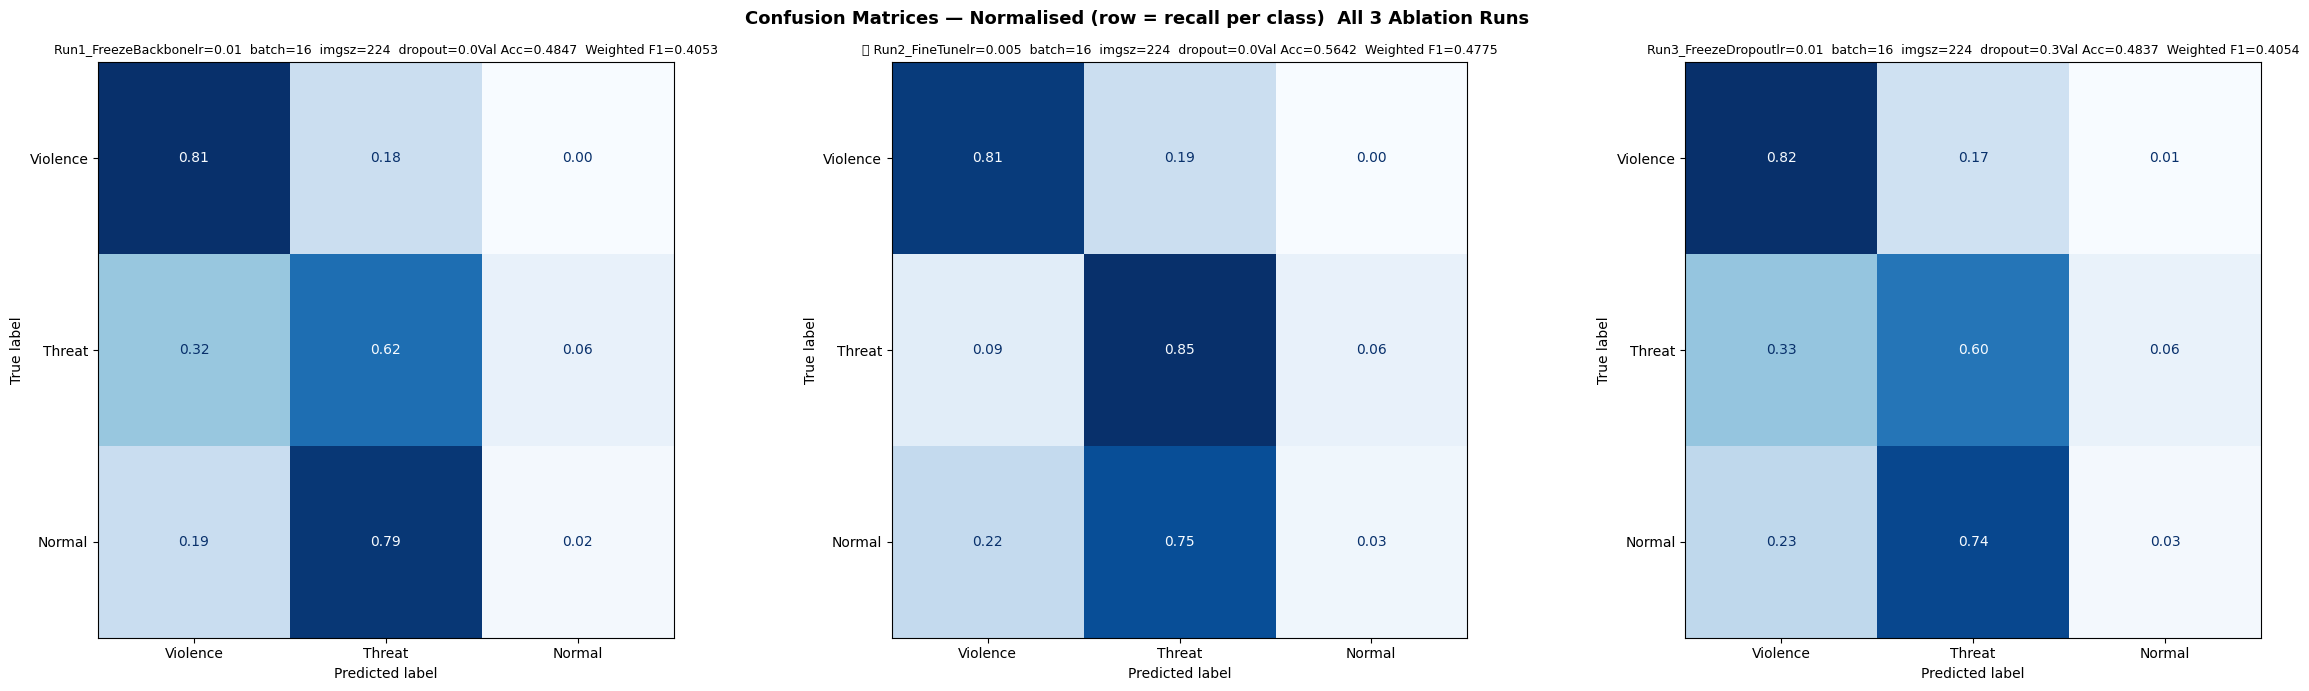

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, res in zip(axes.flatten(), all_results):
    y_t = res['y_true']; y_p = res['y_pred']
    cm  = confusion_matrix(y_t, y_p)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    disp = ConfusionMatrixDisplay(cm_norm, display_labels=TARGET_CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')

    s    = next(s for s in eval_summaries if s['name']==res['name'])
    crown = '🏆 ' if s['wf1'] == best_f1 else ''
    ax.set_title(f'{crown}{res["name"]}'
                 f'lr={res["lr0"]}  batch={res["batch"]}  '
                 f'imgsz={res["imgsz"]}  dropout={res["dropout"]}'
                 f'Val Acc={s["acc"]:.4f}  Weighted F1={s["wf1"]:.4f}',
                 fontsize=9)

plt.suptitle(f'Confusion Matrices — Normalised (row = recall per class)  All {len(all_results)} Ablation Runs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10) Per-Class Metric Bar Chart

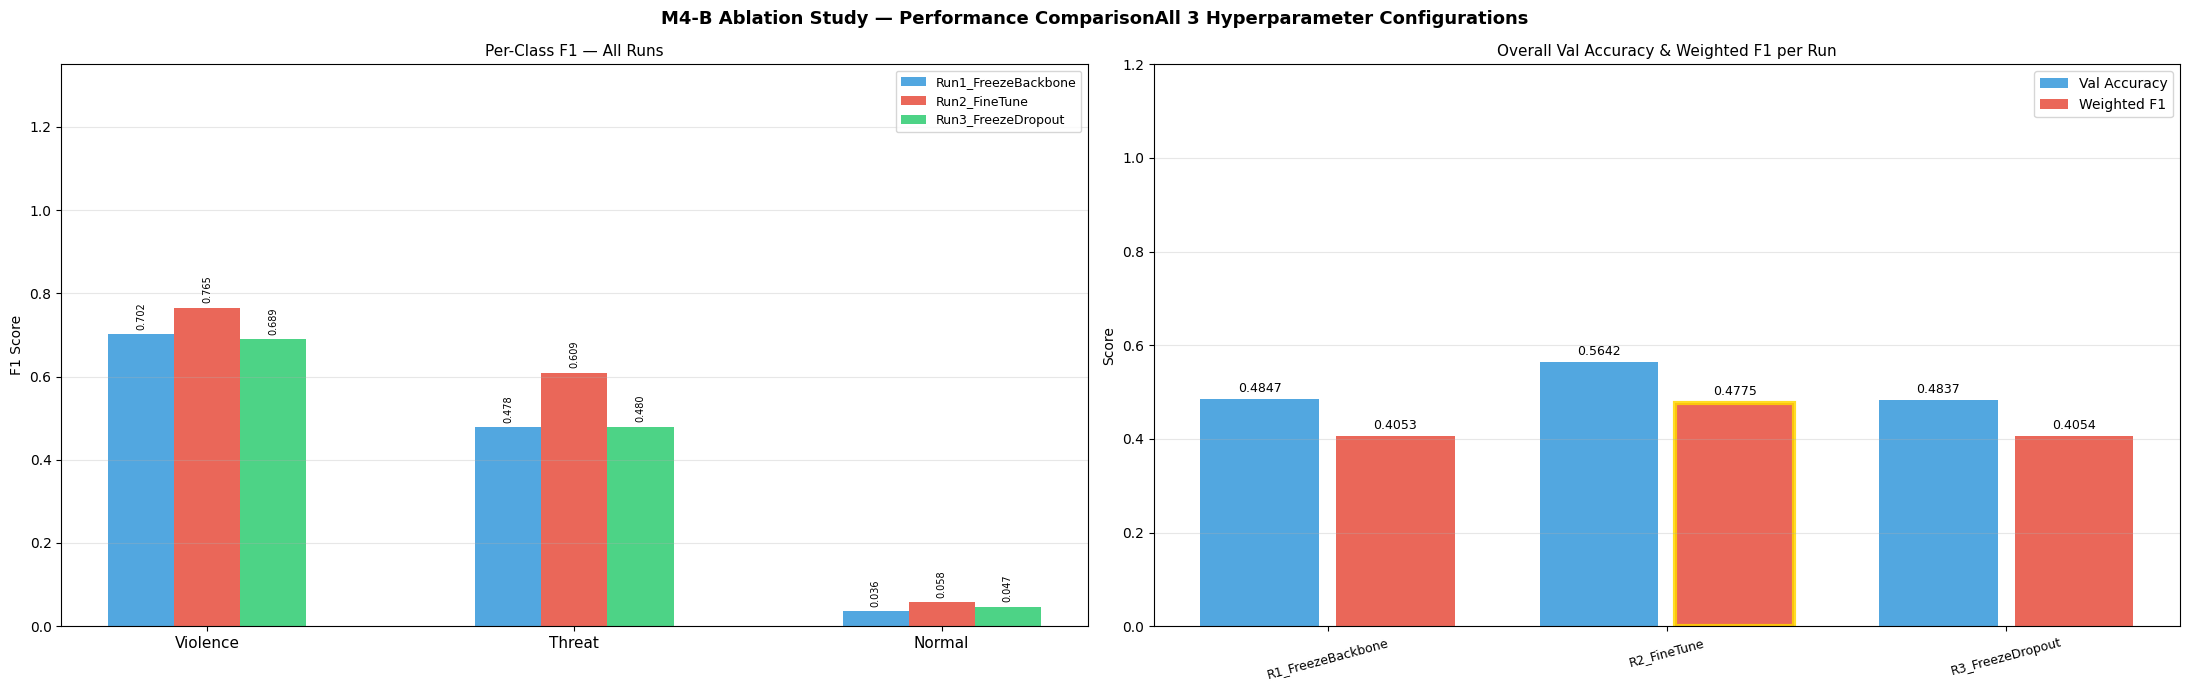

In [12]:
# ── Grouped bar chart: F1 per class, all 4 runs ───────────────────────────────
COLORS = ['#3498DB','#E74C3C','#2ECC71','#F39C12']

x  = np.arange(len(TARGET_CLASSES))
w  = 0.18
n  = len(all_results)

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# Left — F1 per class per run
for i, (res, color) in enumerate(zip(all_results, COLORS)):
    s    = next(s for s in eval_summaries if s['name']==res['name'])
    bars = axes[0].bar(x + (i - n/2 + 0.5)*w, s['f1'], w,
                       label=res['name'], color=color, alpha=0.85)
    axes[0].bar_label(bars, fmt='%.3f', padding=3, fontsize=7, rotation=90)

axes[0].set_xticks(x)
axes[0].set_xticklabels(TARGET_CLASSES, fontsize=11)
axes[0].set_ylim(0, 1.35)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Per-Class F1 — All Runs', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Right — Summary: ValAcc + WeightedF1 side by side per run
run_names = [r['name'].replace('Run','R') for r in all_results]
accs = [s['acc'] for s in eval_summaries]
wf1s = [s['wf1'] for s in eval_summaries]
xr   = np.arange(len(all_results))

b1 = axes[1].bar(xr - 0.2, accs, 0.35, label='Val Accuracy',   color='#3498DB', alpha=0.85)
b2 = axes[1].bar(xr + 0.2, wf1s, 0.35, label='Weighted F1',    color='#E74C3C', alpha=0.85)
axes[1].bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
axes[1].bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
axes[1].set_xticks(xr)
axes[1].set_xticklabels(run_names, fontsize=9, rotation=15)
axes[1].set_ylim(0, 1.2)
axes[1].set_ylabel('Score')
axes[1].set_title('Overall Val Accuracy & Weighted F1 per Run', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# Highlight best bar
best_i = np.argmax(wf1s)
axes[1].patches[len(all_results) + best_i].set_edgecolor('#FFD700')
axes[1].patches[len(all_results) + best_i].set_linewidth(3)

plt.suptitle('M4-B Ablation Study — Performance Comparison'
             f'All {len(all_results)} Hyperparameter Configurations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11) Confidence Score Distribution
Shows how confident the model is on correct vs incorrect predictions.

C:\Users\jingy\AppData\Local\Temp\ipykernel_25396\1555275204.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(class_confs, labels=TARGET_CLASSES, patch_artist=True)


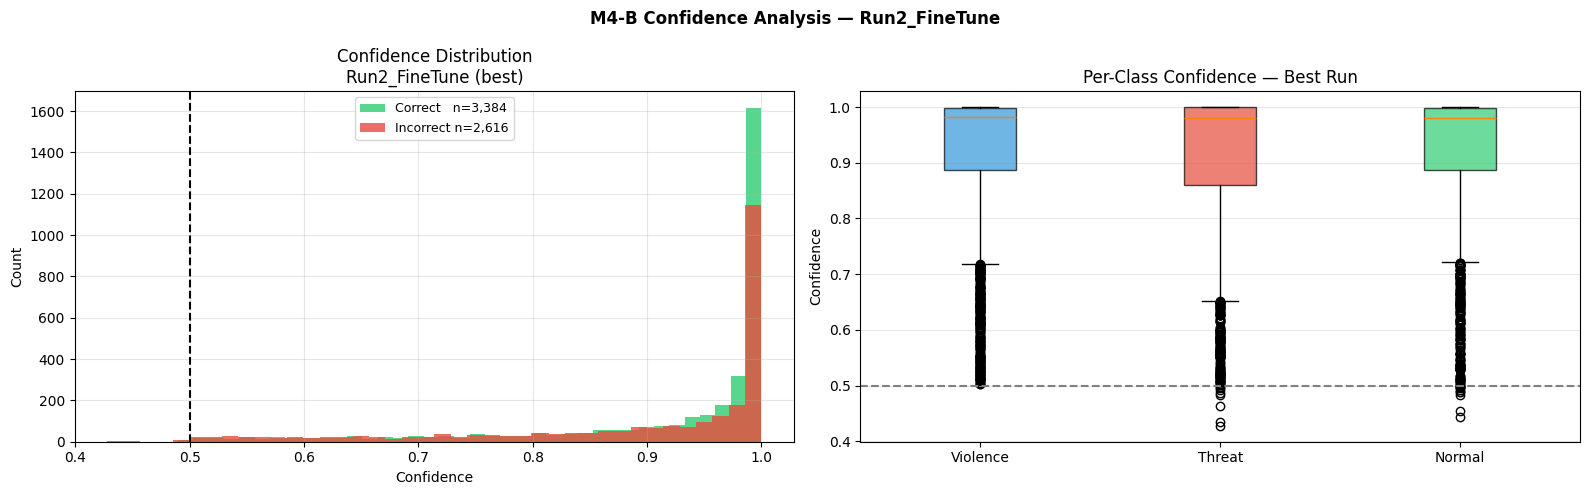

Mean confidence — Correct  : 0.9238
Mean confidence — Incorrect: 0.9000
Separation gap             : 0.0238


In [13]:
# Confidence distribution for the BEST run only
best_res_obj = next(r for r in all_results if r['name']==best_run['name'])

# Re-run inference with confidence scores (ablation eval subsampled — redo full)
val_model  = YOLO(M4B_WEIGHTS)
y_true_f, y_pred_f, y_conf_f = [], [], []
val_root   = Path(FRAMES_ROOT) / 'val'

for ci, cls in enumerate(TARGET_CLASSES):
    cls_dir = val_root / cls
    if not cls_dir.exists(): continue
    for img_path in cls_dir.glob('*.jpg'):
        res      = val_model(str(img_path), imgsz=best_run['imgsz'],
                             verbose=False)[0]
        pred_nm  = res.names[res.probs.top1]
        pred_idx = TARGET_CLASSES.index(pred_nm) if pred_nm in TARGET_CLASSES else -1
        y_true_f.append(ci); y_pred_f.append(pred_idx)
        y_conf_f.append(float(res.probs.top1conf))

y_true_f = np.array(y_true_f)
y_pred_f = np.array(y_pred_f)
y_conf_f = np.array(y_conf_f)

correct_conf   = y_conf_f[y_true_f == y_pred_f]
incorrect_conf = y_conf_f[y_true_f != y_pred_f]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(correct_conf,   bins=40, color='#2ECC71', alpha=0.8,
             label=f'Correct   n={len(correct_conf):,}')
axes[0].hist(incorrect_conf, bins=40, color='#E74C3C', alpha=0.8,
             label=f'Incorrect n={len(incorrect_conf):,}')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Confidence Distribution\n{best_run["name"]} (best)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

class_confs = [y_conf_f[y_true_f==i].tolist() for i in range(len(TARGET_CLASSES))]
bp = axes[1].boxplot(class_confs, labels=TARGET_CLASSES, patch_artist=True)
for patch, c in zip(bp['boxes'], ['#3498DB','#E74C3C','#2ECC71']):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_ylabel('Confidence'); axes[1].axhline(0.5, color='grey', linestyle='--')
axes[1].set_title('Per-Class Confidence — Best Run'); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'M4-B Confidence Analysis — {best_run["name"]}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean confidence — Correct  : {correct_conf.mean():.4f}')
print(f'Mean confidence — Incorrect: {incorrect_conf.mean():.4f}')
print(f'Separation gap             : {correct_conf.mean()-incorrect_conf.mean():.4f}')

## 12) Final Summary & Integration Guide

In [14]:
from sklearn.metrics import precision_recall_fscore_support

best_s   = next(s for s in eval_summaries if s['name']==best_run['name'])
prec, rec, f1, sup = precision_recall_fscore_support(
    y_true_f, y_pred_f,
    labels=list(range(len(TARGET_CLASSES))), zero_division=0)

SEP = '='*70
print(SEP)
print('  M4-B ABLATION STUDY — FINAL RESULTS')
print(f'  Dataset: UCF-Crime  |  Classes: {TARGET_CLASSES}')
print(f'  Base model: {BASE_MODEL}  |  Runs: {len(EXPERIMENTS)}')
print(SEP)
print()
print(f'  {"Run":<22} {"lr0":>7} {"batch":>6} {"imgsz":>6} {"drop":>5} '
      f'{"BestEp":>7} {"ValAcc":>9} {"WtdF1":>9}')
print('  ' + '-'*76)
for s in eval_summaries:
    crown = '🏆' if s['wf1'] == best_f1 else '  '
    print(f'  {s["name"]:<22} {s["lr0"]:>7.4f} {s["batch"]:>6} {s["imgsz"]:>6} '
          f'{s["dropout"]:>5.1f} {s["best_epoch"]:>7} '
          f'{s["acc"]:>9.4f} {s["wf1"]:>9.4f}  {crown}')
print()
print(SEP)
print(f'  🏆 BEST RUN : {best_run["name"]}')
print(f'     {best_run["description"]}')
print(f'     lr0={best_run["lr0"]}  batch={best_run["batch"]}  '
      f'imgsz={best_run["imgsz"]}  dropout={best_run["dropout"]}')
print(f'     Val Accuracy  : {best_s["acc"]:.4f}')
print(f'     Weighted F1   : {best_s["wf1"]:.4f}')
print(f'     Best epoch    : {best_s["best_epoch"]} / {best_run["epochs"]}')
print(f'     Weights saved : {M4B_WEIGHTS}')
print()
print(f'  Per-class (best run):')
print(f'  {"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
print('  ' + '-'*58)
for i, cls in enumerate(TARGET_CLASSES):
    print(f'  {cls:<14} {prec[i]:>10.4f} {rec[i]:>10.4f} '
          f'{f1[i]:>10.4f} {int(sup[i]):>10,}')
print()
print(SEP)
print('  PIPELINE INTEGRATION')
print(SEP)
print(f'  M4B_WEIGHTS    = r\'{M4B_WEIGHTS}\'')
print(f'  TARGET_CLASSES = {TARGET_CLASSES}')
print( '  M4B_CONF_THRESH = 0.50')
print()
print( '  def m4b_predict(frame):')
print( '      res = m4b_model(frame, verbose=False)[0]')
print( '      cls_name = TARGET_CLASSES[res.probs.top1]')
print( '      conf     = float(res.probs.top1conf)')
print( '      return cls_name, conf, cls_name != \'Normal\' and conf > M4B_CONF_THRESH')
print()
print(SEP)
print('  FYP WRITE-UP NOTES')
print(SEP)
print('  Table 1: Hyperparameter ablation — use the comparison table above')
print('  Table 2: Per-class metrics of best run — use the per-class table above')
print('  Figure:  Training curves + confusion matrix grids already generated')
print('  M4-A handles loitering (rule-based, dwell-time > 10s)')
print('  M4-B handles active threats (ML, Fighting/Assault detection)')
print('  Either channel triggers M5 → ALERT')

  M4-B ABLATION STUDY — FINAL RESULTS
  Dataset: UCF-Crime  |  Classes: ['Violence', 'Threat', 'Normal']
  Base model: yolov8s-cls.pt  |  Runs: 3

  Run                        lr0  batch  imgsz  drop  BestEp    ValAcc     WtdF1
  ----------------------------------------------------------------------------
  Run1_FreezeBackbone     0.0100     16    224   0.0      42    0.4847    0.4053    
  Run2_FineTune           0.0050     16    224   0.0      14    0.5642    0.4775  🏆
  Run3_FreezeDropout      0.0100     16    224   0.3      14    0.4837    0.4054    

  🏆 BEST RUN : Run2_FineTune
     Full fine-tune, moderate LR
     lr0=0.005  batch=16  imgsz=224  dropout=0.0
     Val Accuracy  : 0.5642
     Weighted F1   : 0.4775
     Best epoch    : 14 / 50
     Weights saved : D:\FYP-2\notebook\runs\classify\runs\M4B_classifier\Run2_FineTune\weights\best.pt

  Per-class (best run):
  Class           Precision     Recall         F1    Support
  ---------------------------------------------------

## ── Section 13: Temporal Persistence Evaluation ───────────────────────────────
### Instead of per-frame accuracy, evaluate event-level accuracy using a
### sliding window majority vote. This mirrors how M4-B is used in the pipeline.

In [15]:
from collections import deque
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

WINDOW_SIZE = 10      # number of consecutive frames to consider
THRESHOLD   = 0.6     # fraction of window that must agree (≥6/10)

def temporal_smoother(predictions, window=WINDOW_SIZE, threshold=THRESHOLD):
    """Apply sliding window majority vote to a sequence of predictions."""
    smoothed = []
    buf = deque(maxlen=window)
    for pred in predictions:
        buf.append(pred)
        counts = {}
        for p in buf:
            counts[p] = counts.get(p, 0) + 1
        best = max(counts, key=counts.get)
        if counts[best] / len(buf) >= threshold:
            smoothed.append(best)
        else:
            smoothed.append(len(TARGET_CLASSES) - 1)  # default → Normal (last class)
    return smoothed


# ── Re-run inference on val set, grouped BY VIDEO SOURCE ─────────────────────
# Group frames by their source video (filename prefix) so the window
# doesn't bleed across video boundaries
print('Running temporal persistence evaluation on best model...')
print(f'Window={WINDOW_SIZE} frames  Threshold={THRESHOLD} ({int(THRESHOLD*WINDOW_SIZE)}/{WINDOW_SIZE} agreement)')
print()

val_model = YOLO(M4B_WEIGHTS)
val_root  = Path(FRAMES_ROOT) / 'val'

# Collect predictions grouped by video
video_preds  = {}   # video_stem → list of (true_label, pred_label)

for ci, cls in enumerate(TARGET_CLASSES):
    cls_dir = val_root / cls
    if not cls_dir.exists():
        continue
    for img_path in sorted(cls_dir.glob('*.jpg')):
        # Extract video stem (everything before _fXXXXX)
        stem = '_'.join(img_path.stem.split('_')[:-1])
        key  = f'{cls}/{stem}'
        if key not in video_preds:
            video_preds[key] = {'true': [], 'pred': []}
        res      = val_model(str(img_path), imgsz=best_run['imgsz'], verbose=False)[0]
        pred_nm  = res.names[res.probs.top1]
        pred_idx = TARGET_CLASSES.index(pred_nm) if pred_nm in TARGET_CLASSES else -1
        video_preds[key]['true'].append(ci)
        video_preds[key]['pred'].append(pred_idx)

# ── Apply temporal smoothing per video ───────────────────────────────────────
y_true_raw, y_pred_raw = [], []
y_true_smooth, y_pred_smooth = [], []

for key, data in video_preds.items():
    y_true_raw.extend(data['true'])
    y_pred_raw.extend(data['pred'])
    smoothed = temporal_smoother(data['pred'])
    y_true_smooth.extend(data['true'])
    y_pred_smooth.extend(smoothed)

# ── Compare frame-level vs event-level ───────────────────────────────────────
acc_raw    = accuracy_score(y_true_raw,    y_pred_raw)
f1_raw     = f1_score(y_true_raw,    y_pred_raw,    average='weighted', zero_division=0)
acc_smooth = accuracy_score(y_true_smooth, y_pred_smooth)
f1_smooth  = f1_score(y_true_smooth, y_pred_smooth, average='weighted', zero_division=0)

print('='*60)
print(f'  {"Metric":<25} {"Frame-level":>12} {"With Persistence":>16}')
print('  ' + '-'*55)
print(f'  {"Val Accuracy":<25} {acc_raw:>12.4f} {acc_smooth:>16.4f}  {"▲" if acc_smooth > acc_raw else "▼"} {abs(acc_smooth-acc_raw):+.4f}')
print(f'  {"Weighted F1":<25} {f1_raw:>12.4f} {f1_smooth:>16.4f}  {"▲" if f1_smooth > f1_raw else "▼"} {abs(f1_smooth-f1_raw):+.4f}')
print('='*60)
print()

print('Per-class — Frame-level:')
print(classification_report(y_true_raw, y_pred_raw,
      target_names=TARGET_CLASSES, zero_division=0))
print()
print(f'Per-class — With Persistence (window={WINDOW_SIZE}, threshold={THRESHOLD}):')
print(classification_report(y_true_smooth, y_pred_smooth,
      target_names=TARGET_CLASSES, zero_division=0))

Running temporal persistence evaluation on best model...
Window=10 frames  Threshold=0.6 (6/10 agreement)

  Metric                     Frame-level With Persistence
  -------------------------------------------------------
  Val Accuracy                    0.5640           0.5705  ▲ +0.0065
  Weighted F1                     0.4773           0.4880  ▲ +0.0106

Per-class — Frame-level:
              precision    recall  f1-score   support

    Violence       0.72      0.81      0.77      2000
      Threat       0.47      0.85      0.61      2000
      Normal       0.34      0.03      0.06      2000

    accuracy                           0.56      6000
   macro avg       0.51      0.56      0.48      6000
weighted avg       0.51      0.56      0.48      6000


Per-class — With Persistence (window=10, threshold=0.6):
              precision    recall  f1-score   support

    Violence       0.74      0.82      0.78      2000
      Threat       0.49      0.86      0.62      2000
      Norma